# Using the HSC snATAC-seq

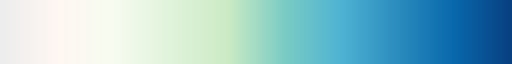

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)

exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

### Get peak-by-cell count matrix

In [2]:
work_dir = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/chromvar'

### Calculate chromVAR motif sores

We have reimplemented chromVAR in scPrinter with significantly improved speed (with GPU speed-up). We now use scPrinter to calculate chromVAR motif scores for each TF in single cells.

In [ ]:
python /cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/chromvar/run_analysis.py

### Visualize cells on UMAP

In [29]:
chromvar = anndata.read_h5ad(f'{work_dir}/chromvar_cisbp_GW16.h5ad')
print(chromvar.X.shape)

(21039, 1141)


In [30]:
chromvar

# tf_list = pd.DataFrame(index=chromvar.var_names)
# tf_list.to_csv('chromvar_TF_list.csv')

AnnData object with n_obs × n_vars = 21039 × 1141
    obs: 'sample', 'id_st', 'cluster_rna'
    obsm: 'spatial'

In [31]:
# Normalize each feature (TF) to mean 0 and variance 1
# max_value=3 clips extreme outliers at 3 to preserve overall color contrast
sc.pp.scale(chromvar, max_value=3)

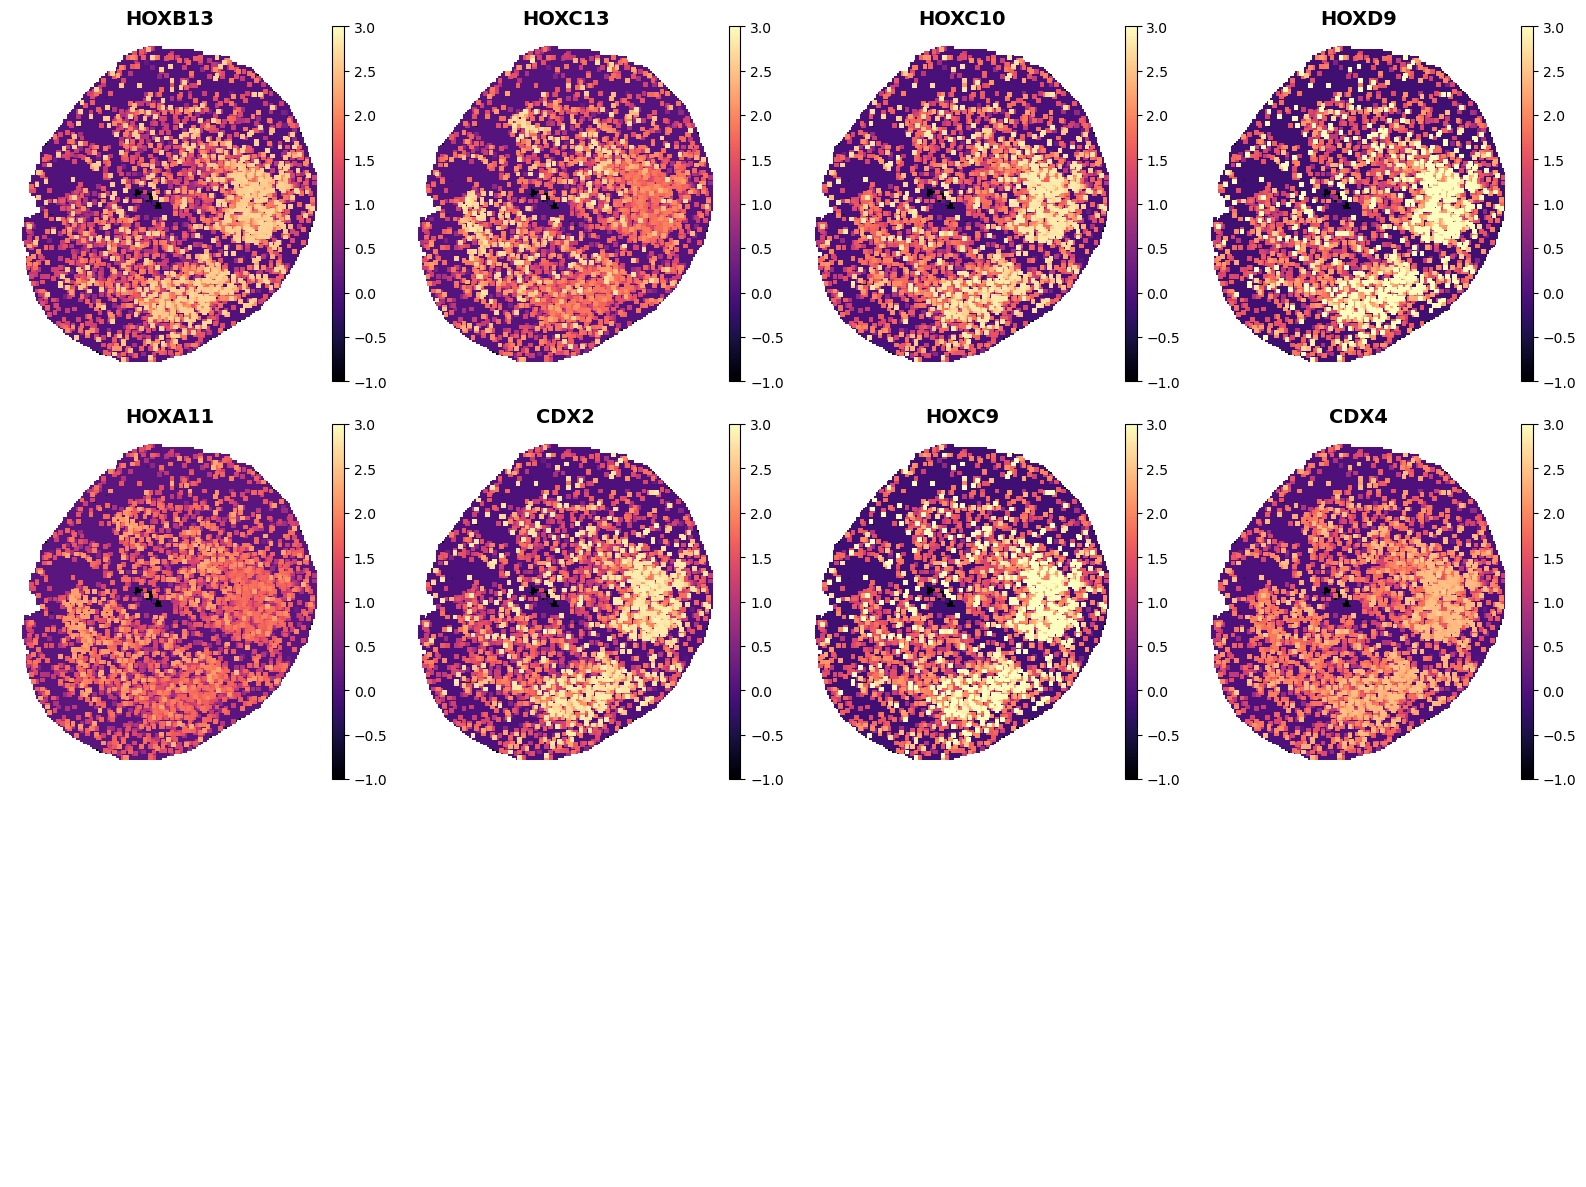

In [32]:
import matplotlib.pyplot as plt
import scanpy as sc

# 2. Define the gene list to plot
genes_to_plot = [ "HOXB13", "HOXC13", "HOXC10","HOXD9", "HOXA11", "CDX2", "HOXC9", "CDX4"]

# 3. Create a canvas: 3 rows x 4 columns (12 slots total)
fig, axes = plt.subplots(3, 4, figsize=(16, 12)) # Recommended size for readability

# Key step: flatten the 2D axes array into 1D
axes_flat = axes.flatten()

for i, gene in enumerate(genes_to_plot):
    # axes_flat[i] is now a single Axes object
    ax = axes_flat[i]
    
    # Plot
    sc.pl.embedding(
        chromvar,
        basis='spatial',
        color=gene,
        marker='s',
        size=12, 
        edgecolor='none',
        cmap='magma',
        vmin=-1, 
        vmax=3,
        frameon=False,
        ax=ax,          # Pass a single subplot
        show=False      
    )

    # 4. Set equal axis aspect ratio
    ax.set_aspect('equal')
    ax.set_title(gene, fontsize=14, fontweight='bold')

# 5. Extra optimization: hide unused empty subplots
# There are 12 slots but only 11 genes, so the last slot (index 11) is empty
if len(genes_to_plot) < len(axes_flat):
    for j in range(len(genes_to_plot), len(axes_flat)):
        axes_flat[j].axis('off')

# 6. Auto-adjust layout
plt.tight_layout()

# 7. Save and show
plt.savefig("./plot/GW16_spatial_TF_HOX.pdf", dpi=300, bbox_inches='tight')
plt.show()

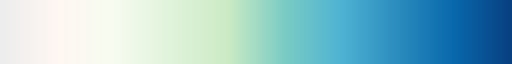

In [108]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)

exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

Displaying TF batch 41 (indices 400 to 409):
['MAFG', 'MAFK', 'MAX', 'MAZ', 'MBD2', 'MBNL2', 'MECOM', 'MECP2', 'MEF2A', 'MEF2B']


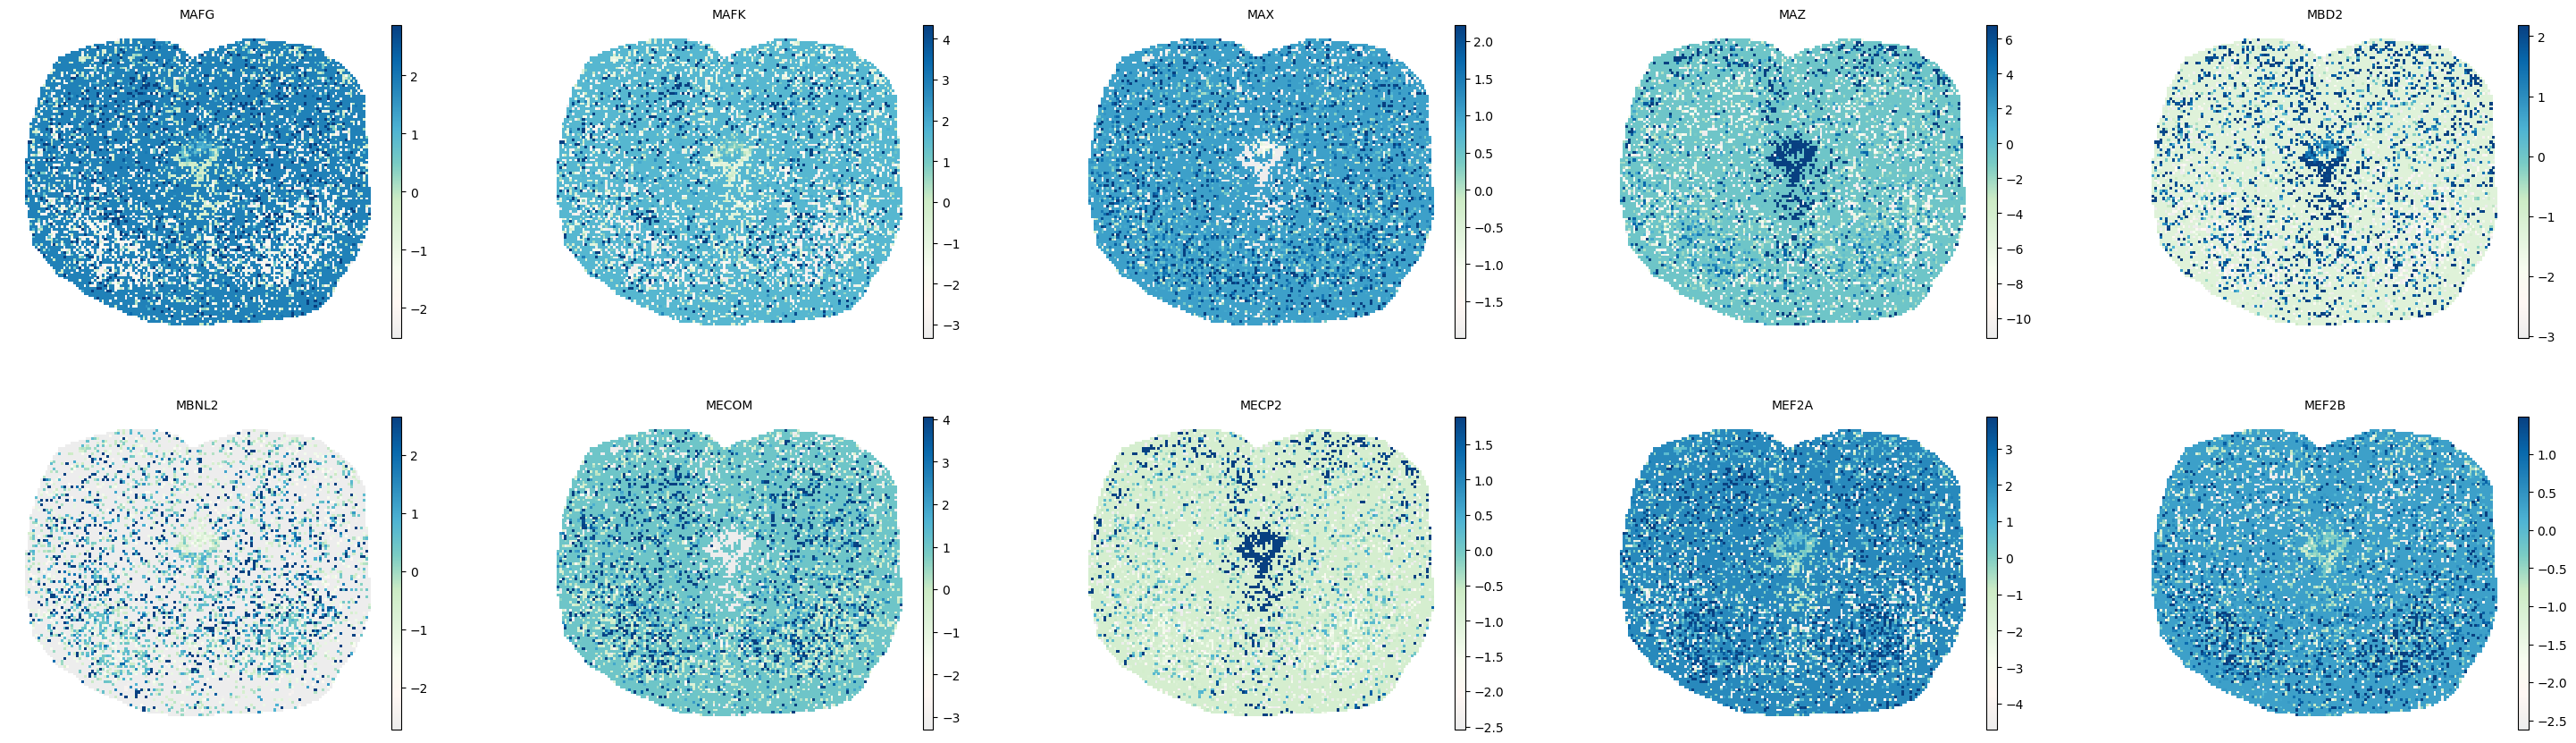

In [27]:
import scanpy as sc
import matplotlib.pyplot as plt

# --- Parameter setup ---
tfs = chromvar.var_names.tolist()  # Get complete TF list
batch_size = 10                    # Show 10 TFs per batch
start_batch = 40                    # Start from this batch (0 means the first 10 TFs)
num_batches_to_show = 1            # Number of batches shown per run (1-2 recommended)

# Ensure exp_cmap is defined; uncomment the next line if needed
# exp_cmap = 'magma' 

# --- Loop logic ---
for i in range(start_batch, start_batch + num_batches_to_show):
    start = i * batch_size
    end = start + batch_size
    
    # Prevent index overflow
    if start >= len(tfs):
        print("All TFs have been displayed.")
        break
    
    current_tfs = tfs[start:end]
    print(f"Displaying TF batch {i+1} (indices {start} to {end-1}):")
    print(current_tfs)

    # Plot
    # scanpy embedding automatically creates subplots when color is a list
    axes = sc.pl.embedding(
        chromvar,
        basis='spatial',
        color=current_tfs,
        marker='s',
        size=5,               # Tuned marker size
        edgecolor='none',
        cmap=exp_cmap,
        vmin='p5', 
        vmax='p95',
        frameon=False,
        ncols=5,               # 5 panels per row, so 10 panels span 2 rows
        show=False,
        return_fig=False
    )

    # Uniformly set aspect ratio for each subplot
    # sc.pl.embedding returns an axes array
    if hasattr(axes, '__iter__'):
        for ax in axes:
            ax.set_aspect('equal')
            ax.set_title(ax.get_title(), fontsize=10) # Slightly reduce title size to avoid overlap
    else:
        axes.set_aspect('equal')

    plt.show()